In [11]:
# Для анализа и разметки данных
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from PIL import Image, ImageOps
from IPython.display import display, clear_output
import csv
import random
from sklearn.preprocessing import StandardScaler

# Для обучения RankNet
import wandb
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from scipy.stats import kendalltau
import copy

In [2]:
wandb.login() # вставить API ключ от аккаунта W&B

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

  2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

  ········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: rimedheart (rimedheart-personal-use) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [5]:
features_df = pd.read_csv('/kaggle/input/datasets/neuromant/building-features-300-final-fit/building_features_300.csv')
features_df['building_name'] = features_df['building_name'].astype(str)
features_df.set_index('building_name', inplace=True)

# Нормализация 
scaler = StandardScaler()
scaled_values = scaler.fit_transform(features_df.values)
features_df_scaled = pd.DataFrame(scaled_values, index=features_df.index, columns=features_df.columns)
class PairwiseDataset(Dataset):
    def __init__(self, pairs_df, features_df_scaled, session_name):
        self.features_a, self.features_b, self.labels = [], [], []
        feature_cols = [f"{session_name}_mean", f"{session_name}_max", f"{session_name}_prevalence"]
        
        for _, row in pairs_df.iterrows():
            img_a, img_b, winner = str(row['image_a']), str(row['image_b']), str(row['winner'])
            if winner not in ['0', '1', '2']: continue
            if img_a not in features_df_scaled.index or img_b not in features_df_scaled.index: continue
                
            # Берем нормализованные векторы
            vec_a = features_df_scaled.loc[img_a, feature_cols].values.astype(np.float32)
            vec_b = features_df_scaled.loc[img_b, feature_cols].values.astype(np.float32)
            
            label = 1.0 if winner == '0' else (0.0 if winner == '1' else 0.5)
            self.features_a.append(vec_a)
            self.features_b.append(vec_b)
            self.labels.append(label)
            
        self.features_a = np.array(self.features_a)
        self.features_b = np.array(self.features_b)
        self.labels = np.array(self.labels, dtype=np.float32)
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx):
        return torch.tensor(self.features_a[idx]), torch.tensor(self.features_b[idx]), torch.tensor(self.labels[idx])

In [18]:
class RankNetHead(nn.Module):
    def __init__(self, input_dim=3):
        super(RankNetHead, self).__init__()
        # Инициализируем 3 веса как обучаемый тензор (начинаем с микро-плюсиков)
        self.weights = nn.Parameter(torch.ones(1, input_dim) * 0.1)
        
    def get_positive_weights(self):
        # ЖЕСТКОЕ ОГРАНИЧЕНИЕ: Берем модуль от весов. Они НИКОГДА 
        # не смогут стать отрицательными, как бы градиент ни старался.
        return torch.abs(self.weights)

    def forward(self, x_a, x_b): 
        w = self.get_positive_weights()
        score_a = F.linear(x_a, w)
        score_b = F.linear(x_b, w)
        return score_a - score_b
        
    def predict_score(self, x): 
        w = self.get_positive_weights()
        return torch.sigmoid(F.linear(x, w))


SESSIONS = ['coating_deterioration', 'cracks', 'masonry_degradation', 'moisture_bio_damage', 'vandalism']
trained_models = {}

for session in SESSIONS:
    pairs_file = f'/kaggle/input/datasets/neuromant/ranking-dataset-300-imgs/ranking_dataset- 300-imgs/ranking_pairs_{session}.csv'
    if not os.path.exists(pairs_file): continue
        
    pairs_df = pd.read_csv(pairs_file)
    
    train_df, val_df = train_test_split(pairs_df, test_size=0.2, random_state=42)
    
    train_dataset = PairwiseDataset(train_df, features_df_scaled, session)
    val_dataset = PairwiseDataset(val_df, features_df_scaled, session)
        
    train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
    # Для валидации берем размер батча = размеру всей выборки, чтобы посчитать Tau-b один раз
    val_loader = DataLoader(val_dataset, batch_size=len(val_dataset), shuffle=False) 
    
    model = RankNetHead(input_dim=3)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    wandb.init(project="master-thesis-ranknet", name=f"run_{session}", reinit=True)
    
    print(f"\n--- Обучение: {session.upper()} (Train: {len(train_dataset)} | Val: {len(val_dataset)}) ---")
    EPOCHS = 50
    for epoch in range(EPOCHS):
        model.train()
        total_loss = 0.0
        
        # Обучение
        for vec_a, vec_b, labels in train_loader:
            optimizer.zero_grad()
            diff_scores = model(vec_a, vec_b).squeeze(-1)
            loss = criterion(diff_scores, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            
        epoch_loss = total_loss / len(train_loader)
        
        # Валидация
        model.eval()
        with torch.no_grad():
            for val_a, val_b, val_labels in val_loader:
                val_diff_scores = model(val_a, val_b).squeeze(-1)
                val_loss = criterion(val_diff_scores, val_labels).item()
                
                # РАСЧЕТ TAU-B ПО ВСЕЙ ВАЛИДАЦИОННОЙ ВЫБОРКЕ (включая ties)
                # scipy.stats.kendalltau автоматически обрабатывает связи (Tau-b)
                # Если дисперсии нет (например, модель выдает одни нули), tau может вернуть NaN
                tau_b, _ = kendalltau(val_labels.numpy(), val_diff_scores.numpy())
                if np.isnan(tau_b):
                    tau_b = 0.0
        
        wandb.log({"epoch": epoch, "train_loss": epoch_loss, "val_loss": val_loss, "val_tau_b": tau_b})
            
        if (epoch+1) % 10 == 0:
            print(f"Epoch {epoch+1:03d}/{EPOCHS} | Train Loss: {epoch_loss:.4f} | Val Loss: {val_loss:.4f} | Val Tau-b: {tau_b:.3f}")
            
    trained_models[session] = model
    wandb.finish()

print("\nОбучение завершено!")



--- Обучение: COATING_DETERIORATION (Train: 164 | Val: 41) ---
Epoch 010/50 | Train Loss: 0.5356 | Val Loss: 0.5229 | Val Tau-b: 0.543
Epoch 020/50 | Train Loss: 0.5141 | Val Loss: 0.4928 | Val Tau-b: 0.543
Epoch 030/50 | Train Loss: 0.4768 | Val Loss: 0.4782 | Val Tau-b: 0.539
Epoch 040/50 | Train Loss: 0.4881 | Val Loss: 0.4703 | Val Tau-b: 0.539
Epoch 050/50 | Train Loss: 0.4768 | Val Loss: 0.4666 | Val Tau-b: 0.539


epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
train_loss,███▇▆▅▆▅▆▅▅▄▄▄▄▄▃▃▄▄▂▂▄▂▂▂▁▃▃▂▂▂▂▂▂▃▁▁▁▂
val_loss,█▇▇▇▆▆▅▅▅▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁
val_tau_b,██████████████████████▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,49
train_loss,0.47684
val_loss,0.46665
val_tau_b,0.5394



--- Обучение: CRACKS (Train: 81 | Val: 21) ---
Epoch 010/50 | Train Loss: 0.6422 | Val Loss: 0.6625 | Val Tau-b: 0.322
Epoch 020/50 | Train Loss: 0.6179 | Val Loss: 0.6575 | Val Tau-b: 0.322
Epoch 030/50 | Train Loss: 0.6388 | Val Loss: 0.6530 | Val Tau-b: 0.322
Epoch 040/50 | Train Loss: 0.6662 | Val Loss: 0.6497 | Val Tau-b: 0.309
Epoch 050/50 | Train Loss: 0.6336 | Val Loss: 0.6474 | Val Tau-b: 0.309


epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
train_loss,▆▆▆▆▅▃▆▆▅▅▆▆▆▄▅▅▆▃▄█▅▃▂▅▄▆▅▅▅▁▅▆▅▅▅▅▄▅▃▅
val_loss,██▇▇▇▇▇▆▆▆▆▅▅▅▅▅▄▄▄▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁
val_tau_b,█████████████████████████████▁▁▁▁▁▁▁▁▁▁▁
epoch,49
train_loss,0.63364
val_loss,0.64736
val_tau_b,0.30883



--- Обучение: MASONRY_DEGRADATION (Train: 157 | Val: 40) ---
Epoch 010/50 | Train Loss: 0.5113 | Val Loss: 0.5617 | Val Tau-b: 0.448
Epoch 020/50 | Train Loss: 0.4961 | Val Loss: 0.5573 | Val Tau-b: 0.462
Epoch 030/50 | Train Loss: 0.4836 | Val Loss: 0.5571 | Val Tau-b: 0.458
Epoch 040/50 | Train Loss: 0.4861 | Val Loss: 0.5582 | Val Tau-b: 0.458
Epoch 050/50 | Train Loss: 0.4786 | Val Loss: 0.5591 | Val Tau-b: 0.466


...


--- Обучение: MOISTURE_BIO_DAMAGE (Train: 169 | Val: 43) ---
Epoch 010/50 | Train Loss: 0.5265 | Val Loss: 0.5443 | Val Tau-b: 0.484
Epoch 020/50 | Train Loss: 0.4942 | Val Loss: 0.5207 | Val Tau-b: 0.484
Epoch 030/50 | Train Loss: 0.4760 | Val Loss: 0.5102 | Val Tau-b: 0.490
Epoch 040/50 | Train Loss: 0.4688 | Val Loss: 0.5055 | Val Tau-b: 0.487
Epoch 050/50 | Train Loss: 0.4713 | Val Loss: 0.5037 | Val Tau-b: 0.487


epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇███
train_loss,█▇▇▇▆▅▅▅▅▄▄▄▄▃▃▃▃▂▃▃▃▂▂▂▂▁▂▂▁▂▁▁▁▁▁▁▁▁▁▁
val_loss,█▇▇▆▆▅▅▅▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_tau_b,▄▄▄▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▄██████▄▄▄▄▄▄▄▄▄▄▄▄▄▄
epoch,49
train_loss,0.47132
val_loss,0.50366
val_tau_b,0.4872



--- Обучение: VANDALISM (Train: 109 | Val: 28) ---
Epoch 010/50 | Train Loss: 0.4788 | Val Loss: 0.4319 | Val Tau-b: 0.578
Epoch 020/50 | Train Loss: 0.4578 | Val Loss: 0.4095 | Val Tau-b: 0.578
Epoch 030/50 | Train Loss: 0.4425 | Val Loss: 0.3975 | Val Tau-b: 0.578
Epoch 040/50 | Train Loss: 0.4439 | Val Loss: 0.3904 | Val Tau-b: 0.578
Epoch 050/50 | Train Loss: 0.4325 | Val Loss: 0.3859 | Val Tau-b: 0.578


epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇██
train_loss,█▇▇▆▆▅▅▅▄▄▄▄▃▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▂▂▁▁▁▁▁▁▁
val_loss,██▇▇▆▆▅▅▅▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁
val_tau_b,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,49
train_loss,0.4325
val_loss,0.38594
val_tau_b,0.57846



Обучение завершено!


## Другой вариант RankNet

In [17]:
class RankNetHead(nn.Module):
    def __init__(self, input_dim=3, hidden_dim=8, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),   # стабилизирует обучение на малых данных
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1)    # скалярный score
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x_a, x_b):
        """Возвращает разность score_a - score_b (logit для BCEWithLogitsLoss)"""
        return self.net(x_a).squeeze(-1) - self.net(x_b).squeeze(-1)

    def predict_score(self, x):
        """Абсолютный score для ранжирования на инференсе"""
        with torch.no_grad():
            return torch.sigmoid(self.net(x))


SESSIONS = ['coating_deterioration', 'cracks', 'masonry_degradation', 'moisture_bio_damage', 'vandalism']
trained_models = {}

for session in SESSIONS:
    pairs_file = f'/kaggle/input/datasets/neuromant/ranking-dataset-300-imgs/ranking_dataset- 300-imgs/ranking_pairs_{session}.csv'
    if not os.path.exists(pairs_file): continue
        
    pairs_df = pd.read_csv(pairs_file)
    
    # 1. ЧЕСТНЫЙ СПЛИТ 80/20 (Валидация)
    if len(pairs_df) < 20:
        continue
    train_df, val_df = train_test_split(pairs_df, test_size=0.2, random_state=42)
    
    train_dataset = PairwiseDataset(train_df, features_df_scaled, session)
    val_dataset = PairwiseDataset(val_df, features_df_scaled, session)
        
    train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
    # Для валидации берем размер батча = размеру всей выборки, чтобы посчитать Tau-b один раз
    val_loader = DataLoader(val_dataset, batch_size=len(val_dataset), shuffle=False) 
    
    model = RankNetHead(input_dim=3, hidden_dim=16, dropout=0.3)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
    # weight_decay — L2 регуляризация, дополнительная защита от переобучения

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=10)

    best_tau = -1
    patience_counter = 0
    PATIENCE = 20

# В конце эпохи: scheduler.step(tau_b)
    
    wandb.init(project="master-thesis-ranknet", name=f"run_{session}", reinit=True)
    
    print(f"\n--- Обучение: {session.upper()} (Train: {len(train_dataset)} | Val: {len(val_dataset)}) ---")
    EPOCHS = 100
    for epoch in range(EPOCHS):
        model.train()
        total_loss = 0.0
        
        # Обучение
        for vec_a, vec_b, labels in train_loader:
            optimizer.zero_grad()
            diff_scores = model(vec_a, vec_b)
            loss = criterion(diff_scores, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            
        epoch_loss = total_loss / len(train_loader)
        
        # Валидация
        model.eval()
        with torch.no_grad():
            for val_a, val_b, val_labels in val_loader:
                val_diff_scores = model(val_a, val_b)
                val_loss = criterion(val_diff_scores, val_labels).item()
                
                # РАСЧЕТ TAU-B ПО ВСЕЙ ВАЛИДАЦИОННОЙ ВЫБОРКЕ (включая ties)
                # scipy.stats.kendalltau автоматически обрабатывает связи (Tau-b)
                # Если дисперсии нет (например, модель выдает одни нули), tau может вернуть NaN
                tau_b, _ = kendalltau(val_labels.numpy(), val_diff_scores.numpy())
                if np.isnan(tau_b):
                    tau_b = 0.0

        if tau_b > best_tau:
            best_tau = tau_b
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print(f"Early stopping на эпохе {epoch+1}")
                model.load_state_dict(best_state)  # откатываемся к лучшей
                break

        scheduler.step(tau_b)
        
        wandb.log({"epoch": epoch, "train_loss": epoch_loss, "val_loss": val_loss, "val_tau_b": tau_b})
            
        if (epoch+1) % 20 == 0:
            print(f"Epoch {epoch+1:03d}/{EPOCHS} | Train Loss: {epoch_loss:.4f} | Val Loss: {val_loss:.4f} | Val Tau-b: {tau_b:.3f}")
            
    trained_models[session] = model
    wandb.finish()

print("\nОбучение завершено!")



--- Обучение: COATING_DETERIORATION (Train: 164 | Val: 41) ---
Epoch 020/100 | Train Loss: 0.5855 | Val Loss: 0.5103 | Val Tau-b: 0.410
Epoch 040/100 | Train Loss: 0.5581 | Val Loss: 0.4793 | Val Tau-b: 0.523
Epoch 060/100 | Train Loss: 0.4577 | Val Loss: 0.4729 | Val Tau-b: 0.546
Epoch 080/100 | Train Loss: 0.4707 | Val Loss: 0.4700 | Val Tau-b: 0.553
Early stopping на эпохе 91


epoch,▁▁▁▁▂▂▂▃▃▃▃▃▄▄▄▅▅▅▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇████
train_loss,██▅▃▄▃▃▄▂▂▄▃▂▃▂▃▂▂▃▂▂▂▂▂▁▁▂▁▁▂▂▂▂▂▂▂▂▂▁▁
val_loss,█▇▄▄▄▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_tau_b,▁▂▃▅▆▇▇▇▇▇▇▇▇███████████████████████████
epoch,89
train_loss,0.46542
val_loss,0.46804
val_tau_b,0.55272



--- Обучение: CRACKS (Train: 81 | Val: 21) ---
Epoch 020/100 | Train Loss: 0.7480 | Val Loss: 0.7092 | Val Tau-b: 0.141
Epoch 040/100 | Train Loss: 0.5811 | Val Loss: 0.7189 | Val Tau-b: 0.142
Early stopping на эпохе 55


epoch,▁▁▁▁▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▇▇▇▇▇▇███
train_loss,▆▅█▇▃▅▃▅▁▅▃▂▆▃▁▅▄▂▂▄▄▃▄▃▄▄▂▂▄▂▃▁▃▃▄▂▃▃▄▂
val_loss,█▇▇▆▅▄▃▃▃▃▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂
val_tau_b,▁▂▂▄▅▆▇▆▆▆▆▇▇█▇▇▇██████▇██▇▇▇██▇████████
epoch,53
train_loss,0.5919
val_loss,0.71398
val_tau_b,0.14155



--- Обучение: MASONRY_DEGRADATION (Train: 157 | Val: 40) ---
Epoch 020/100 | Train Loss: 0.5433 | Val Loss: 0.5823 | Val Tau-b: 0.441
Early stopping на эпохе 39


...


--- Обучение: MOISTURE_BIO_DAMAGE (Train: 169 | Val: 43) ---
Epoch 020/100 | Train Loss: 0.4812 | Val Loss: 0.5996 | Val Tau-b: 0.372
Epoch 040/100 | Train Loss: 0.4694 | Val Loss: 0.5725 | Val Tau-b: 0.428
Epoch 060/100 | Train Loss: 0.4569 | Val Loss: 0.5501 | Val Tau-b: 0.431
Early stopping на эпохе 66


epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇████
train_loss,█▆▅▅▃▄▄▃▃▃▂▃▂▃▃▃▃▃▂▂▁▂▂▂▂▂▂▂▂▁▂▁▁▂▁▂▁▂▂▁
val_loss,█▇▆▅▅▄▄▄▃▄▃▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁
val_tau_b,▁▃▄▅▆▇▇▇▇▇▇▇▇▇▇▇▇███████████████████████
epoch,64
train_loss,0.40866
val_loss,0.54816
val_tau_b,0.43134



--- Обучение: VANDALISM (Train: 109 | Val: 28) ---
Epoch 020/100 | Train Loss: 0.6603 | Val Loss: 0.7031 | Val Tau-b: 0.053
Epoch 040/100 | Train Loss: 0.5582 | Val Loss: 0.6502 | Val Tau-b: 0.186
Epoch 060/100 | Train Loss: 0.5699 | Val Loss: 0.6308 | Val Tau-b: 0.213
Epoch 080/100 | Train Loss: 0.5784 | Val Loss: 0.6171 | Val Tau-b: 0.219
Early stopping на эпохе 92


epoch,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇██
train_loss,█▇▇▆▆▄▅▄▄▄▄▃▃▃▃▃▃▃▂▂▂▂▁▂▂▂▂▁▂▂▂▂▂▁▁▂▂▂▂▂
val_loss,█▇▆▅▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_tau_b,▁▁▁▁▁▁▂▄▅▅▇▇▇▇▇▇▇▇▇█████████████████████
epoch,90
train_loss,0.55865
val_loss,0.61252
val_tau_b,0.23271



Обучение завершено!


In [19]:
results = []

for b_name, row in features_df.iterrows():
    b_dict = {'building_name': b_name}
    
    for session, model in trained_models.items():
        feature_cols = [f"{session}_mean", f"{session}_max", f"{session}_prevalence"]
        
        # Берем вектор (1 батч, 3 фичи)
        vec = row[feature_cols].values.astype(np.float32)
        vec_tensor = torch.tensor(vec).unsqueeze(0) 
        
        with torch.no_grad():
            score = model.predict_score(vec_tensor).item()
            
        b_dict[f"{session}_score"] = score
        
    results.append(b_dict)

final_scores_df = pd.DataFrame(results)

score_cols = [col for col in final_scores_df.columns if '_score' in col]

# Нормализуем индивидуальные скоры от 0.0 до 1.0 (Min-Max Scaling)
for col in score_cols:
    min_val = final_scores_df[col].min()
    max_val = final_scores_df[col].max()
    
    # Защита от деления на ноль
    if max_val > min_val:
        final_scores_df[col] = (final_scores_df[col] - min_val) / (max_val - min_val)
    else:
        final_scores_df[col] = 0.0

# Теперь пересчитываем Глобальный Индекс на основе выровненных от 0 до 1 баллов
final_scores_df['Global_Damage_Index'] = final_scores_df[score_cols].mean(axis=1)


# Выводим Топ-10 самых "убитых"
final_scores_df.sort_values(by='Global_Damage_Index', ascending=False, inplace=True)
display(final_scores_df.head(10))


,building_name,coating_deterioration_score,cracks_score,masonry_degradation_score,moisture_bio_damage_score,vandalism_score,Global_Damage_Index
22,IMG_20260410_141005863_HDR,1.000000,0.293186,0.158617,0.479117,0.120753,0.410334
241,DSC02210,0.530637,0.415428,0.536295,0.447470,0.066089,0.399184
51,9,0.670709,0.098600,0.342495,0.326142,0.492479,0.386085
132,DSC02259,0.796937,0.000000,0.594741,0.127394,0.383021,0.380419
158,IMG_20260317_113335801_HDR,0.827838,0.000000,0.649917,0.158812,0.174284,0.362170
58,32,0.640147,0.000000,0.121006,1.000000,0.000000,0.352231
99,61,0.601320,0.012816,0.029448,0.111145,1.000000,0.350946
258,IMG_20260410_135002890_HDR,0.707457,0.057802,0.000000,0.880744,0.103716,0.349944
283,DSC02200,0.553041,0.810462,0.000000,0.321909,0.000000,0.337082
181,IMG_20260318_080042286_HDR,0.761843,0.272277,0.295860,0.351441,0.000000,0.336284


In [8]:
# Можно сохранить финал:
final_scores_df.to_csv('facade_damage_scores_ranked.csv', index=False)

,coating_deterioration_score,cracks_score,masonry_degradation_score,moisture_bio_damage_score,vandalism_score
count,300.000000,300.000000,300.000000,300.000000,300.000000
mean,0.342141,0.067484,0.068689,0.220413,0.048031
std,0.249204,0.138043,0.123329,0.214811,0.110111
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.133742,0.000000,0.000000,0.044089,0.000000
50%,0.293305,0.012816,0.029448,0.158363,0.000000
75%,0.519096,0.077678,0.076247,0.338005,0.066370
max,1.000000,1.000000,1.000000,1.000000,1.000000


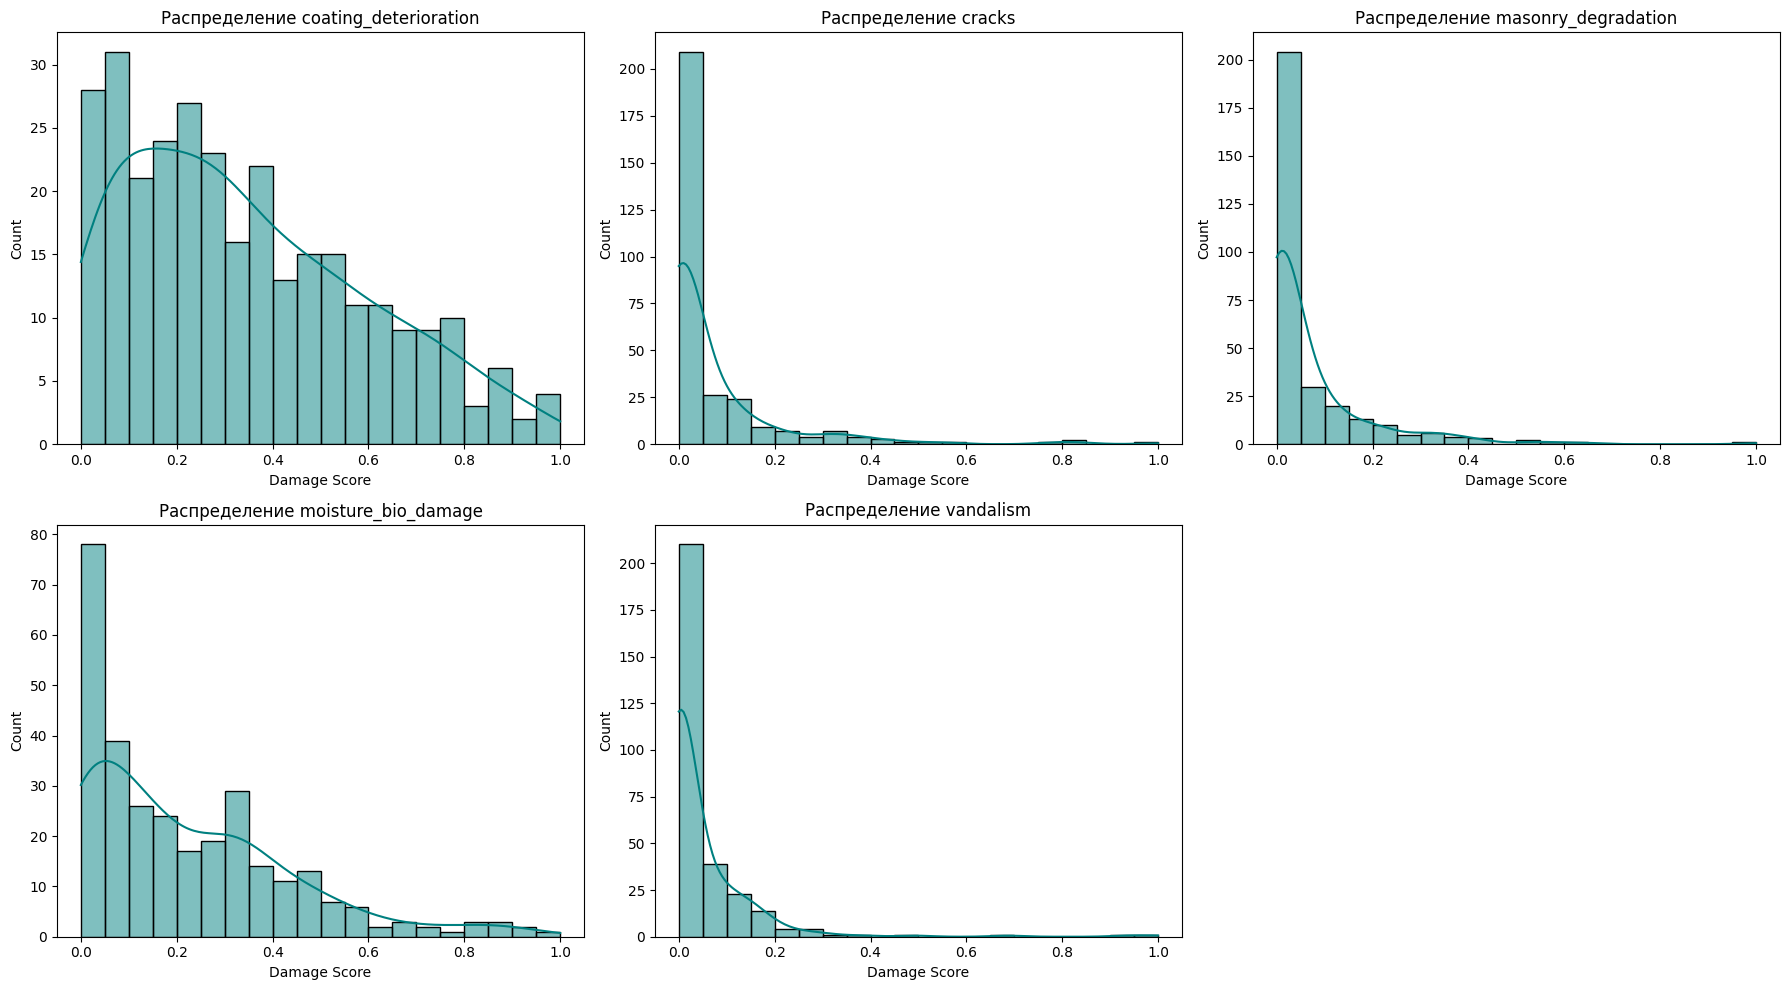

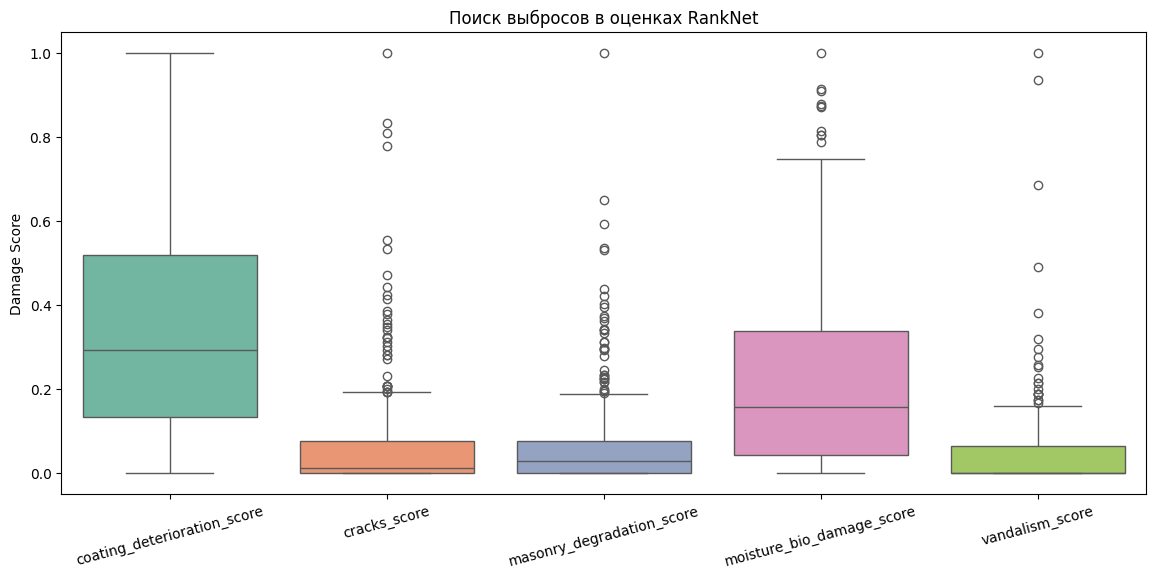

\Топ самых поврежденных зданий

Топ-5 худших по COATING_DETERIORATION:
 - Фасад: IMG_20260410_141005863_HDR.jpg (Оценка RankNet: 1.000)
 - Фасад: IMG_20260410_135231599_HDR.jpg (Оценка RankNet: 0.960)
 - Фасад: IMG_20260410_134735979_HDR.jpg (Оценка RankNet: 0.959)
 - Фасад: IMG_20260410_141636397_HDR.jpg (Оценка RankNet: 0.959)
 - Фасад: IMG_20260410_140721246_HDR.jpg (Оценка RankNet: 0.928)

Топ-5 худших по CRACKS:
 - Фасад: 49.jpg (Оценка RankNet: 1.000)
 - Фасад: DSC02515.jpg (Оценка RankNet: 0.833)
 - Фасад: DSC02200.jpg (Оценка RankNet: 0.810)
 - Фасад: DSC02223.jpg (Оценка RankNet: 0.780)
 - Фасад: IMG_20260410_141818968_HDR.jpg (Оценка RankNet: 0.557)

Топ-5 худших по MASONRY_DEGRADATION:
 - Фасад: IMG_20260319_121325656_HDR.jpg (Оценка RankNet: 1.000)
 - Фасад: IMG_20260317_113335801_HDR.jpg (Оценка RankNet: 0.650)
 - Фасад: DSC02259.jpg (Оценка RankNet: 0.595)
 - Фасад: DSC02210.jpg (Оценка RankNet: 0.536)
 - Фасад: IMG_20260320_160147.jpg (Оценка RankNet: 0.531)

Топ-5 худши

In [20]:
# Вывод статистик
display(final_scores_df[score_cols].describe())

# Распределения
plt.figure(figsize=(18, 10))
for i, col in enumerate(score_cols, 1):
    plt.subplot(2, 3, i)
    sns.histplot(final_scores_df[col], bins=20, kde=True, color='teal')
    plt.title(f'Распределение {col.replace("_score", "")}')
    plt.xlabel("Damage Score")
plt.tight_layout()
plt.show()

# Выбросы
# Попробуем понять, является ли супер-разрушенный фасад аномалией 
# или равномерно вписывается в общий тренд
plt.figure(figsize=(14, 6))
sns.boxplot(data=final_scores_df[score_cols], palette="Set2")
plt.xticks(rotation=15)
plt.title("Поиск выбросов в оценках RankNet")
plt.ylabel("Damage Score")
plt.show()

# Визуальное сопоставление (sanity check)
print("\Топ самых поврежденных зданий")
for col in score_cols:
    top_buildings = final_scores_df.nlargest(5, col)[['building_name', col]]
    clean_name = col.replace('_score', '').upper()
    print(f"\nТоп-5 худших по {clean_name}:")
    for _, row in top_buildings.iterrows():
        print(f" - Фасад: {row['building_name']}.jpg (Оценка RankNet: {row[col]:.3f})")
